In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Defining a Band-pass filter
Here, I plan to use the steady-state response of a simple circuit of 2 resistor-capacitor pairs, creating a band-pass filter in the frequency domain. By stacking multiple filters with controllable RC properties, we can create a tunable response in frequency space.

The transfer function of the bandpass filter is defined by:

$\Large \mid H(f) \mid = \mid\frac{j 2\pi f R C_1}{1 + j 2\pi f R C_1} \cdot \frac{1}{1 + j 2\pi f R C_2} \mid$


In [2]:
def band_pass(Vin, R, C1, C2, f):
    return Vin*np.abs(((2j*np.pi*f*R*C1)/(1+2j*np.pi*f*R*C1))*(1/(1+2j*np.pi*f*R*C2)))

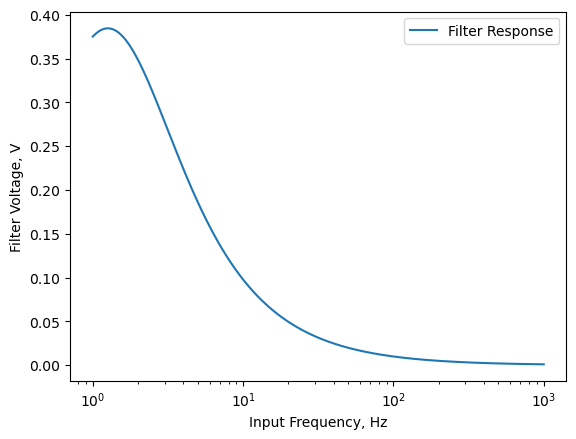

In [3]:
# Plot Frequency response for filter
Vin = 1    # Input voltage of 1 V
R = 10   # Resistor of 10 ohms
C1 = 1e-2   # Capacitor 1 with 10 mF Capacitance
C2 = 1.6e-2 # Capacitor 2 with 16 mF Capacitance
fs = np.logspace(0, 3, 1000) # Logarithmic frequency spread between 1 and 1000 Hz

Hs = np.zeros_like(fs)
for i, f in enumerate(fs):
    Hs[i] = band_pass(Vin, R, C1, C2, f)
    
plt.figure()
plt.semilogx(fs, Hs, label='Filter Response')
plt.legend()
plt.xlabel('Input Frequency, Hz')
plt.ylabel('Filter Voltage, V')
plt.show()

If we add a second filter, the resulting transfer functions are multiplied:

$\Large \mid H_{total}(f) \mid = \mid H_1(f) \mid \cdot \mid H_2(f) \mid $

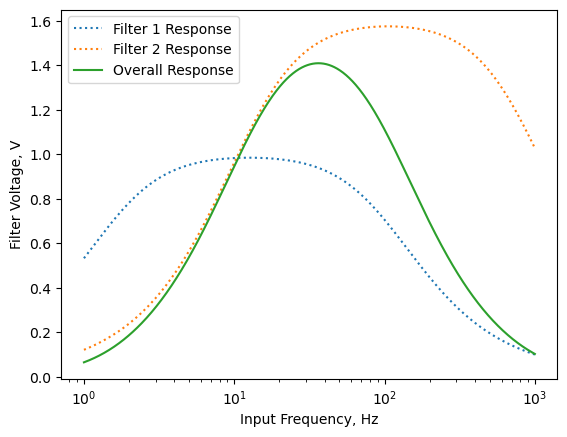

In [4]:
# Params for filter 1
Vin_1 = 1    # Input voltage of 1 V
R_1 = 10   # Resistor of 10 ohms
C1_1 = 1e-2   # Capacitor 1 with 10 mF Capacitance
C2_1 = 1.6e-4 # Capacitor 2 with 0.16 mF Capacitance

# Params for filter 2
Vin_2 = 1.6    # Input current of 1 V
R_2 = 10   # Resistor of 10 ohms
C1_2 = 1.2e-3   # Capacitor 1 with 1.2 mF Capacitance
C2_2 = 1.9e-5 # Capacitor 2 with 0.019 mF Capacitance

fs = np.logspace(0, 3, 1000) # Logarithmic frequency spread between 1 and 1000 Hz


Hs_1 = np.zeros_like(fs)
Hs_2 = np.zeros_like(fs)
for i, f in enumerate(fs):
    Hs_1[i] = band_pass(Vin_1, R_1, C1_1, C2_1, f)
    Hs_2[i] = band_pass(Vin_2, R_2, C1_2, C2_2, f)

# Combined response
Hs_tot = Hs_1 * Hs_2
    
plt.figure()
plt.semilogx(fs, Hs_1, label='Filter 1 Response', ls=':')
plt.semilogx(fs, Hs_2, label='Filter 2 Response', ls=':')
plt.semilogx(fs, Hs_tot, label='Overall Response')
plt.legend()
plt.xlabel('Input Frequency, Hz')
plt.ylabel('Filter Voltage, V')
plt.show()

# Now we would like to optimise the parameters of a series of filters to fit a function translated to frequency space.

As a toy task, we will define a 1d function that the filter bank has to fit:

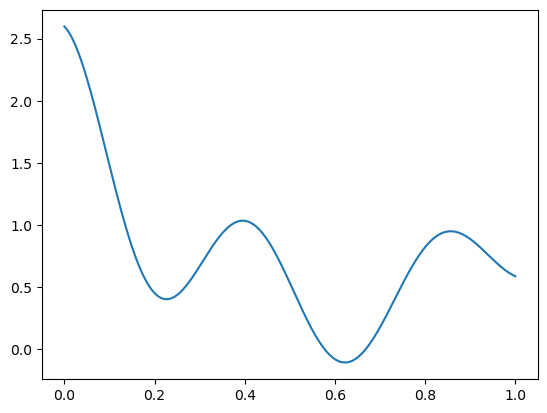

In [5]:
# Define the function to be fitted
def f(s):
    return 0.25*(torch.exp(1/(0.5*s+0.5))*torch.cos(5*s)*torch.cos(10*s)+3)

out = torch.zeros((1000))
s_in = torch.linspace(0, 1, 1000)
for i in range(1000):
    out[i] = f(s_in[i])
    
plt.figure()
plt.plot(s_in, out)
plt.show()

In [6]:
# Define a model to fit the filter parameters
class PhyKAN(nn.Module):
    def __init__(self, Nfilters):
        super().__init__()
        self.Nfilters = Nfilters
        self.filter_params = torch.rand((Nfilters, 4)).double()
        self.filter_params.requires_grad=True
        self.optim = torch.optim.Adam(params={self.filter_params}, lr=1e-2)
        self.lossfn = nn.MSELoss()
    # Redefined for torch & assuming trainable parameters
    def band_pass(self, freq):
        # For 'sensible' initialisation, we'd like parameters that make sense for Vin, R, and C1/C2:
        # Set Vin as between +/- 10 V
        Vins = 20*(self.filter_params[:, 0]-0.5)
        # Set R as between 1 and 100 ohms
        Rs = 10**(2*self.filter_params[:, 1])
        # Set C1 and C2 as between 1 uF and 10 mF
        Cs = 10**(-6 + 4*self.filter_params[:, 2:])
        Hout = torch.zeros_like(freq)
        for i in range(self.Nfilters):
            Hout += Vins[i]*torch.abs(((2j*Rs[i]*Cs[i, 0])/(1+2j*torch.pi*freq*Rs[i]*Cs[i, 0]))*(1/(1+2j*torch.pi*freq*Rs[i]*Cs[i, 1])))
        return Hout
    
    def forward(self, Xin):
        # Normalise input of 0-1 to frequencies of 1-1000 Hz
        freq = 10**(3*Xin)
        # Pass through filter bank
        out = self.band_pass(freq)
        return out
    
    def train(self, Xin, Yin):
        self.optim.zero_grad()
        pred = self.forward(Xin)
        loss = self.lossfn(pred, Yin)
        loss.backward()
        self.optim.step()
        return(loss.item())

0.9872557520866394
0.01902497559785843
0.005981436464935541
0.0030562577303498983
0.0026145786978304386
0.0019977204501628876
0.0010901509085670114
0.0005625098710879683
0.00048450229223817587
0.0012776150833815336


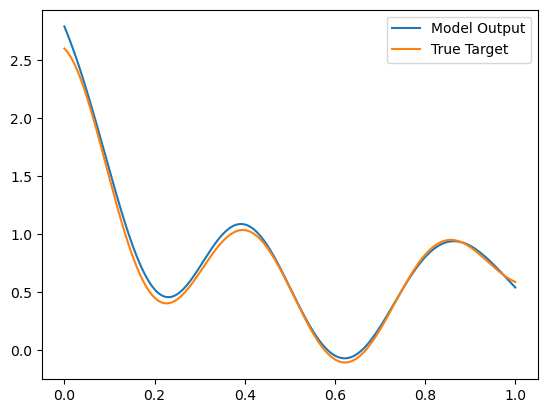

In [7]:
model = PhyKAN(7)

for i in range(100000):
    Xs = torch.rand(1000)
    Ys = f(Xs)
    loss = model.train(Xs, Ys)
    if i%10000 == 0:
        print(loss)
Xs = torch.linspace(0, 1, 1000)
Ys = model.forward(Xs)
Y_True = f(Xs)

fig, ax = plt.subplots()

Xs = torch.linspace(0, 1, 1000)
Ys = model.forward(Xs)
Y_True = f(Xs)
line1, = ax.plot(Xs.cpu().detach().numpy().flatten(), Ys.cpu().detach().numpy().flatten(), label='Model Output')
line2, = ax.plot(Xs.cpu().detach().numpy().flatten(), Y_True.cpu().detach().numpy().flatten(), label='True Target')
plt.legend()
plt.show()


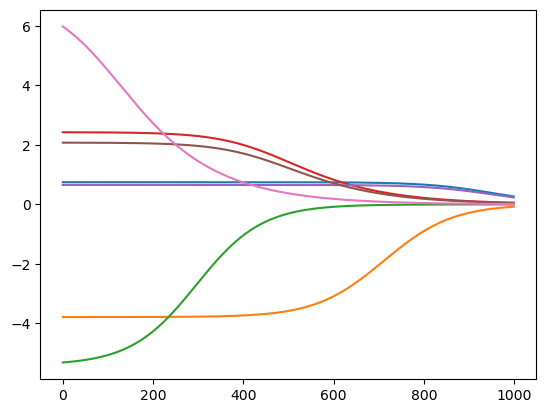

In [14]:
filter_params = model.filter_params.cpu().detach().numpy()

freq = np.logspace(0, 3, 1000) # Logarithmic frequency spread between 1 and 1000 Hz
Vins = 20*(filter_params[:, 0]-0.5)
# Set R as between 1 and 100 ohms
Rs = 10**(2*filter_params[:, 1])
# Set C1 and C2 as between 1 uF and 10 mF
Cs = 10**(-6 + 4*filter_params[:, 2:])
Hout = np.zeros((7, 1000))
for i in range(7):
    Hout[i] = Vins[i]*np.abs(((2j*Rs[i]*Cs[i, 0])/(1+2j*np.pi*freq*Rs[i]*Cs[i, 0]))*(1/(1+2j*np.pi*freq*Rs[i]*Cs[i, 1])))
